# Chartbook — expenditure by ESA economic type

The companion to [`chartbook.ipynb`](chartbook.ipynb), which explains how to
read every chart here (levels, seams, projection shading, captions). This book
holds the third tree, **expenditure by ESA economic type** (`ESA_EXP`,
D-S11-003): nine lines per country that sum to `TE_ESA`, a second cut of the
same total expenditure as the COFOG functions — so an `E` line must never be
added to a `GF` line.

| line | ESA | what it is |
|---|---|---|
| `E01` | D.1 | compensation of employees |
| `E02` | P.2 | intermediate consumption |
| `E03` | D.62 | social benefits other than social transfers in kind — every cash benefit, all functions |
| `E04` | D.632 | social transfers in kind via market producers (purchased health care, etc.) |
| `E05` | D.41 | interest payable — the economic-type twin of COFOG `GF01_7` |
| `E06` | D.3 | subsidies |
| `E07` | D.29 + D.5 + (D.4 − D.41) + D.7 + D.8 | other current expenditure |
| `E08` | P.5 + NP | gross capital formation and net acquisitions of non-produced assets |
| `E09` | D.9 | capital transfers payable |
| `TE_ESA` | total | their sum: the ESA main-aggregates total expenditure |

Sources: Eurostat `gov_10a_main` payable items for France and Germany, ONS ESA
Table 2 payable rows for the UK — the same institution as each country's
anchor, so the identity `E01 + … + E09 = TE_ESA` is exact in every outturn
year (V2). Forecasts: AMECO carries every line on the same ESA concept, so
`E01`–`E07` project to 2027 at grade A for France and Germany, and `E05`
chains into the Debt Sustainability Monitor's interest path to 2036 under
the same committee approval as `GF01_7`; the UK's compensation, intermediate
consumption and other-current lines have no AMECO history to measure
coverage on and stop at the last outturn; `E08` and `E09` have partial
components only (§7.8 proxies, `maximum_extension`). Backward, AMECO takes
the French lines to 1978, the German ones to 1991, the UK ones to 1987 where
the UK history exists.

Every caption states the recipe and how far each variant projects, exactly as
in the main book; "no projection published" and its five reasons mean the same
thing here.


In [1]:
import io
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image as Image_display, display
from PIL import Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "deliverables" / "series_catalogue.csv").exists())
DELIV = ROOT / "deliverables"
load = lambda n: pd.read_csv(DELIV / f"{n}.csv")

EXPENDITURE = load("expenditure_cofog")
ECONOMIC = load("expenditure_esa")   # the ESA_EXP tree, charted in chartbook_esa.ipynb
REVENUE = load("revenue_esa")
TREE = pd.concat([EXPENDITURE, ECONOMIC, REVENUE], ignore_index=True)
LEDGER = load("balance_ledger")
LEVELS = load("weo_levels_bridge")
RECON = load("weo_reconciliation")
CATALOGUE = load("series_catalogue")

LATEST = sorted(LEVELS.weo_vintage.dropna().unique())[-1]
NAME = dict(zip(CATALOGUE.iso3, CATALOGUE.country))

# Categorical slots 1-3 of the validated palette, assigned by entity and never
# reused: blue is always our strict series, orange always the maximum
# extension, aqua always the IMF WEO. Line style repeats the distinction so
# identity never rests on colour alone.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, AXIS = "#0b0b0b", "#898781", "#c3c2b7"
SURFACE, SHADE = "#fcfcfb", "#eceae4"

plt.rcParams.update({
    "figure.figsize": (6.9, 2.7), "figure.dpi": 72,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "grid.color": AXIS, "grid.alpha": 0.45, "grid.linewidth": 0.6,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 2,
})


# Every chart runs from its country's earliest published year to 2031, so any
# two can be laid side by side and read against the same calendar. 2031 is the
# end of the near-term forecast horizon; four series per country carry
# long-term legs to 2036 or 2070, and those run off the right edge with a
# marker saying how far they go. The values are all in the flat files.
XMAX = 2031
XLIM = {}
for _iso in TREE.iso3.unique():
    _years = pd.concat([TREE.query("iso3 == @_iso").year,
                        LEDGER.query("iso3 == @_iso").year])
    _lo = int(_years.min())
    _pad = (XMAX - _lo) * 0.035
    XLIM[_iso] = (_lo - _pad, XMAX + _pad)

# To read all three countries against one calendar instead of one per country,
# uncomment these two lines and re-run from here:
# _LO = min(lo for lo, _ in XLIM.values())
# XLIM = {iso: (_LO, XMAX + (XMAX - _LO) * 0.035) for iso in XLIM}


def _palette():
    """A fixed palette of exactly the colours these charts use.

    Quantising is what keeps this notebook renderable — at full colour depth
    its 100-odd figures came to 3.3 MB, at which size GitHub's notebook
    renderer gives up and shows "Loading" forever. But an *adaptive* palette
    allocates slots by pixel count, and a dashed line has few pixels: at 32
    colours it crushed the orange series to a muddy #927670. So the palette
    is fixed instead — each mark colour exactly, plus its blends toward the
    two backgrounds for antialiasing — and the brand hues survive whatever
    share of the canvas they happen to occupy.
    """
    from matplotlib.colors import to_rgb

    entries = [to_rgb(SURFACE), to_rgb(SHADE)]
    for mark in (INK, MUTED, AXIS, BLUE, ORANGE, AQUA):
        m = to_rgb(mark)
        for ground in (SURFACE, SHADE):
            g = to_rgb(ground)
            entries += [tuple(m[i] + (g[i] - m[i]) * t for i in range(3))
                        for t in (0.0, 0.2, 0.4, 0.6, 0.8)]
    flat = [round(255 * v) for e in entries for v in e]
    pal = Image.new("P", (1, 1))
    pal.putpalette(flat + [0] * (768 - len(flat)))
    return pal


PALETTE = _palette()


def show(fig):
    """Display a figure as a PNG quantised onto that fixed palette."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=plt.rcParams["figure.dpi"])
    plt.close(fig)
    small = Image.open(buf).convert("RGB").quantize(
        palette=PALETTE, dither=Image.Dither.NONE)
    out = io.BytesIO()
    small.save(out, format="PNG", optimize=True)
    display(Image_display(data=out.getvalue()))


def thousands(ax):
    """Levels run to seven figures; unseparated tick labels are unreadable."""
    ax.yaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))


def _seams(g):
    """Years where the source or the construction method changes."""
    g = g.sort_values("year")
    key = list(zip(g.observation_type, g.source_id.fillna("")))
    return [int(y) for (a, b), y in zip(zip(key, key[1:]), g.year[1:]) if a != b]


# Why a series carries no projection. The pipeline records one of five
# statuses per undeclared line; these are the plain-language readings.
WHY_NO_FORECAST = {
    "no_official_forecast":
        "nobody publishes a forecast of this line on a compatible concept",
    "source_blocked":
        "a forecast exists but the publication cannot be ingested",
    "grade_below_strict":
        "the only candidate covers too little of the line to enter strict",
    "no_machine_readable_source":
        "the candidate source has no ESA-complete machine-readable series",
    "not_extended":
        "a total, deliberately not given a forecast path of its own",
}


def _forecast_lines(row):
    """State, in words, how far each variant projects and why it stops."""
    actual = int(row.final_actual_year)
    out = [f"outturn:  {int(row.first_year)}-{actual}"]
    # the recorded reason is prefixed with its own [status] tag, which reads
    # oddly on a line that says the variant does project; the status is said
    # in words below anyway
    untag = lambda t: t.split("] ", 1)[1] if t.startswith("[") else t
    reason = untag(row.reason_series_ends) if isinstance(
        row.reason_series_ends, str) else ""
    note = row.forecast_note if isinstance(row.forecast_note, str) else ""
    status = row.forecast_status if isinstance(row.forecast_status, str) else ""
    headline = WHY_NO_FORECAST.get(status, "")

    def say(end):
        if end > actual:
            return f"projects to {end} — {reason or 'source horizon'}"
        why = note or reason or "no forecast source identified"
        return f"NO PROJECTION — {headline or 'see note'}. {why}"

    strict, maximum = say(int(row.final_strict_year)), say(int(row.final_maximum_year))
    if strict == maximum:                       # the common case: say it once
        out.append(f"{'both:'.ljust(9)} {strict}")
    else:
        out.append(f"{'strict:'.ljust(9)} {strict}")
        out.append(f"{'maximum:'.ljust(9)} {maximum}")
    return out


def _caption(iso3, line_code):
    row = CATALOGUE.query("iso3 == @iso3 and line_code == @line_code").iloc[0]
    recipe = str(row.recipe_maximum_extension).replace(" | ", "  ·  ")
    parts = [fill(f"recipe:   {recipe}", 104, subsequent_indent=" " * 10)]
    parts += [fill(line, 104, subsequent_indent=" " * 10)
              for line in _forecast_lines(row)]
    return "\n".join(parts)


def chart(iso3, line_code, caption=True, xlim=None):
    """One series, both variants, with its seams and projection region.

    `xlim` overrides the shared country axis to zoom in on a stretch.
    """
    g = TREE.query("iso3 == @iso3 and line_code == @line_code")
    strict = g.query("variant == 'strict'").sort_values("year")
    mx = g.query("variant == 'maximum_extension'").sort_values("year")
    label = g.line_label.iloc[0]
    actual = g.query("basis == 'actual'").year.max()
    furthest = int(mx.year.max())

    fig, ax = plt.subplots()
    # The projection region is shaded on every chart, whether or not the
    # series reaches into it: a line that stops at the shading edge is one
    # nobody publishes a forecast for, and that should look different from a
    # line that carries on.
    lo, hi = xlim or XLIM[iso3]
    ax.set_xlim(lo, hi)
    ax.axvspan(actual, hi, color=SHADE, zorder=0, lw=0)
    # Plot only what the window shows, plus one point past the edge so the
    # line reaches it. Without this the y-axis would autoscale to values that
    # are not on the chart, flattening everything that is.
    window = lambda d: d[d.year <= hi + 1]
    if len(mx) > len(strict):
        ax.plot(window(mx).year, window(mx).value_lcu_mn, color=ORANGE,
                ls="--", label="maximum_extension")
    ax.plot(window(strict).year, window(strict).value_lcu_mn, color=BLUE,
            label="strict")
    for year in _seams(mx):
        ax.axvline(year, color=MUTED, ls=":", lw=0.9, alpha=0.8, zorder=1)
    if furthest <= actual:
        ax.annotate("no projection published", (actual, 0.94),
                    xycoords=("data", "axes fraction"),
                    xytext=(4, 0), textcoords="offset points",
                    color=MUTED, fontsize=7.5, va="top")
    elif furthest > hi:
        ax.annotate(f"continues to {furthest} →", (hi, 0.94),
                    xycoords=("data", "axes fraction"),
                    xytext=(-4, 0), textcoords="offset points",
                    color=MUTED, fontsize=7.5, va="top", ha="right")

    ax.set_title(f"{NAME[iso3]} · {line_code} — {label}")
    ax.set_ylabel(f"{g.currency.iloc[0]} mn")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    thousands(ax)
    if len(mx) > len(strict):
        ax.legend(loc="upper left")
    fig.tight_layout()
    show(fig)
    if caption:
        print(_caption(iso3, line_code))


def ledger_chart(iso3, quantity, xlim=None):
    """One balance-ledger quantity. Outturn only; the variants are identical."""
    g = LEDGER.query("iso3 == @iso3 and variant == 'strict'").sort_values("year")
    col = f"{quantity.lower()}_lcu_mn"
    meaning = {"TR": "total revenue (balance anchor's own total)",
               "TE": "total expenditure (balance anchor's own total)",
               "NLB": "net lending (+) / net borrowing (-) = TR - TE",
               "NI": "net interest = GF01_7 - R07",
               "PB": "primary balance = NLB + NI"}[quantity]

    actual = int(g.year.max())
    fig, ax = plt.subplots()
    lo, hi = xlim or XLIM[iso3]
    ax.set_xlim(lo, hi)
    ax.axvspan(actual, hi, color=SHADE, zorder=0, lw=0)
    ax.plot(g.year, g[col], color=BLUE)
    if (g[col] < 0).any():
        ax.axhline(0, color=AXIS, lw=1, zorder=0)
    ax.annotate("no projection published", (actual, 0.94),
                xycoords=("data", "axes fraction"),
                xytext=(4, 0), textcoords="offset points",
                color=MUTED, fontsize=7.5, va="top")
    ax.set_title(f"{NAME[iso3]} · ledger {quantity} — {meaning}")
    ax.set_ylabel(f"{g.currency.iloc[0]} mn")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    thousands(ax)
    fig.tight_layout()
    show(fig)
    missing = g[g[col].isna()].year.tolist()
    print(f"outturn:  {int(g.year.min())}-{actual}, source {g.source_id.iloc[0]}"
          + (f"; no value for {missing}" if missing else ""))
    print(fill("forecast: NO PROJECTION — the ledger is outturn-only by "
               "design. Building it forward would mean summing lines whose "
               "forecast coverage is partial, which would misstate the "
               "totals; the forecast-side comparison lives in section 4 "
               "instead, where the coverage gap is explicit.", 104,
               subsequent_indent=" " * 10))


WEO_Q = {
    "revenue": ("tr_ours_mn", "tr_weo_mn", "gap_tr_pct_te",
                "total revenue", "WEO GGR"),
    "expenditure": ("te_ours_mn", "te_weo_mn", "gap_te_pct_te",
                    "total expenditure", "WEO GGX"),
    "nlb": ("nlb_ours_mn", "nlb_weo_mn", "gap_nlb_pct_te",
            "net lending / borrowing", "WEO GGXCNL"),
}


def weo_chart(iso3, quantity, vintage=None):
    """Ours against the IMF WEO, level and gap, over the overlap years."""
    vintage = vintage or LATEST
    ours_col, weo_col, gap_col, label, weo_label = WEO_Q[quantity]
    g = (LEVELS.query("block == 'history' and iso3 == @iso3 and "
                      "weo_vintage == @vintage").sort_values("year"))
    currency = LEDGER.query("iso3 == @iso3").currency.iloc[0]

    fig, (ax, gx) = plt.subplots(2, 1, figsize=(6.6, 3.8), sharex=True,
                                 height_ratios=[2.6, 1])
    ax.plot(g.year, g[ours_col], color=BLUE, label="ours")
    ax.plot(g.year, g[weo_col], color=AQUA, ls="--", label=weo_label)
    if (g[ours_col] < 0).any():
        ax.axhline(0, color=AXIS, lw=1, zorder=0)

    # Same country axis as sections 1-3, so this chart can be read against
    # them. The comparison itself ends at the last outturn, because our
    # ledger does; the years after it are the shaded projection region with
    # nothing on our side to put in it.
    ax.set_xlim(*XLIM[iso3])
    ax.axvspan(g.year.max(), XLIM[iso3][1], color=SHADE, zorder=0, lw=0)
    ax.annotate("no projection published", (g.year.max(), 0.04),
                xycoords=("data", "axes fraction"),
                xytext=(4, 0), textcoords="offset points",
                color=MUTED, fontsize=7.5, va="bottom")

    # Direct labels: the aqua step sits below 3:1 on this surface, so identity
    # is carried by text on the mark as well as by the legend. The two series
    # nearly coincide by construction, so the labels are staggered off each
    # other rather than drawn on top of one another.
    ends = [(ours_col, BLUE, "ours"), (weo_col, AQUA, weo_label)]
    lo, hi = ax.get_ylim()
    close = abs(g[ours_col].iloc[-1] - g[weo_col].iloc[-1]) < (hi - lo) * 0.06
    for (col, colour, text), dy in zip(ends, (9, -9) if close else (0, 0)):
        y = g[col].iloc[-1]
        # keep the label inside the axes: near the top it would otherwise ride
        # up into the title
        if (y - lo) / (hi - lo) > 0.86:
            dy -= 16
        ax.annotate(text, (g.year.iloc[-1], y),
                    xytext=(6, dy), textcoords="offset points",
                    color=colour, fontsize=8.5, va="center")
    ax.set_title(f"{NAME[iso3]} · {label} — ours vs IMF WEO")
    ax.set_ylabel(f"{currency} mn")
    ax.grid(axis="y")
    thousands(ax)
    ax.legend(loc="upper left")

    gx.plot(g.year, g[gap_col], color=BLUE)
    gx.axhline(0, color=AXIS, lw=1, zorder=0)
    gx.set_ylabel("gap, % of TE")
    gx.grid(axis="y")
    gx.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    fig.tight_layout()
    show(fig)

    gap = g[gap_col]
    kinds = ", ".join(sorted(g.gap_classification.dropna().unique()))
    print(f"WEO vintage {vintage}; overlap {int(g.year.min())}-"
          f"{int(g.year.max())}; gap mean {gap.mean():+.3f}% of TE, "
          f"sigma {gap.std():.3f}, range {gap.min():+.3f} to "
          f"{gap.max():+.3f}; classified: {kinds}")


print(f"loaded {len(TREE):,} tree rows, {len(LEDGER)} ledger rows, "
      f"{len(LEVELS)} bridge rows; WEO vintages "
      f"{', '.join(sorted(LEVELS.weo_vintage.dropna().unique()))}; "
      f"latest {LATEST}")

loaded 10,544 tree rows, 196 ledger rows, 398 bridge rows; WEO vintages 2025-04, 2025-10, 2026-04; latest 2026-04


## 1. United Kingdom — expenditure by ESA economic type

Nine economic lines and their total. `E03` (cash social benefits) and `E05` (interest) are the two that other publications forecast directly; read `E05` against `GF01_7` in the main book.

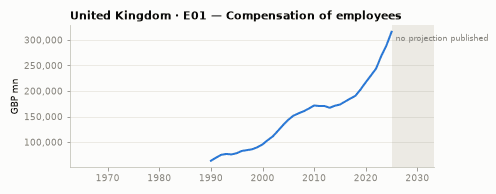

recipe:   1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
both:     NO PROJECTION — the candidate source has no ESA-complete machine-readable series. AMECO
          publishes UK compensation of employees (UWCG) for 2026-27 only, with no history to measure
          §9.2 coverage on (OQ-4 pattern) — recorded, not applied; the EFO's economic breakdown (table
          6.1) starts at FY 2025-26, same problem


In [2]:
chart("GBR", "E01")

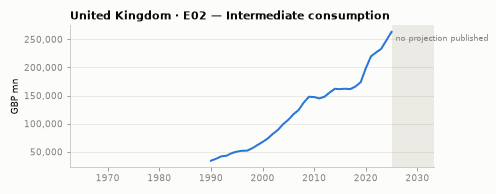

recipe:   1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
both:     NO PROJECTION — the candidate source has no ESA-complete machine-readable series. as E01:
          AMECO UCTGI carries no UK history; EFO 6.1 procurement starts at FY 2025-26


In [3]:
chart("GBR", "E02")

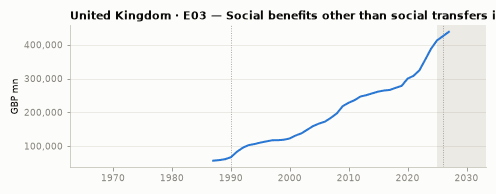

recipe:   1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1987-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [4]:
chart("GBR", "E03")

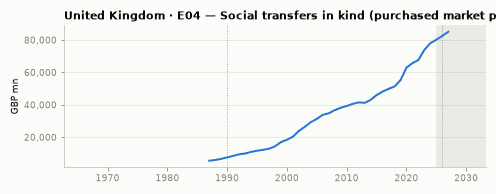

recipe:   1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1987-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [5]:
chart("GBR", "E04")

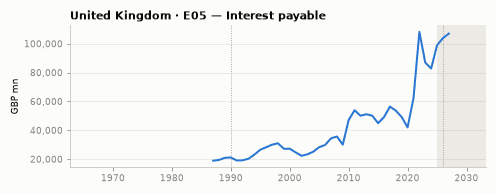

recipe:   1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2027: official forecast (EC_AMECO, grade B)
outturn:  1987-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [6]:
chart("GBR", "E05")

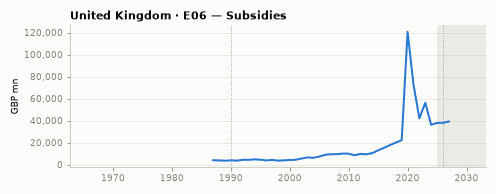

recipe:   1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2027: official forecast (EC_AMECO, grade B)
outturn:  1987-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [7]:
chart("GBR", "E06")

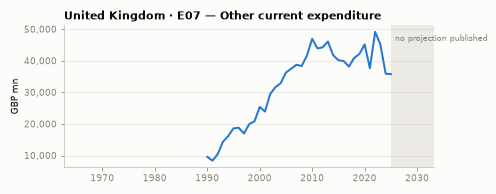

recipe:   1990-2025: derived by identity (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
both:     NO PROJECTION — the candidate source has no ESA-complete machine-readable series. as E01:
          AMECO UUOG carries no UK history


In [8]:
chart("GBR", "E07")

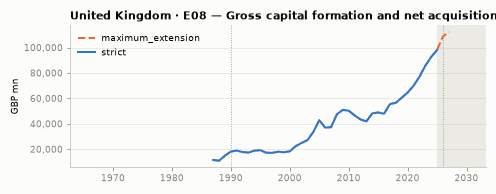

recipe:   1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-2025: derived by identity
          (ONS_GG_RECEIPTS, grade A)  ·  2026-2027: proxy forecast (EC_AMECO, grade B)
outturn:  1987-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UIGG0
          is gross fixed capital formation (P.51G) only — one component of P.5 + NP; §7.8 single-
          component proxy, applied in maximum_extension to 2027 with the measured share; no official
          forecast of inventories/valuables/non-produced assets exists
maximum:  projects to 2027 — AMECO UIGG0 is gross fixed capital formation (P.51G) only — one component
          of P.5 + NP; §7.8 single-component proxy, applied in maximum_extension to 2027 with the
          measured share; no official forecast of inventories/valuables/non-produced assets exists


In [9]:
chart("GBR", "E08")

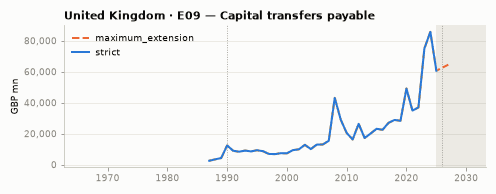

recipe:   1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2027: proxy forecast (EC_AMECO, grade B)
outturn:  1987-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UKTGT
          (D.9 exactly) stops at the last actual; UKOG (other capital expenditure incl. capital
          transfers) is the forecast candidate — a superset proxy (§7.8), maximum_extension only where
          its measured share is in band
maximum:  projects to 2027 — AMECO UKTGT (D.9 exactly) stops at the last actual; UKOG (other capital
          expenditure incl. capital transfers) is the forecast candidate — a superset proxy (§7.8),
          maximum_extension only where its measured share is in band


In [10]:
chart("GBR", "E09")

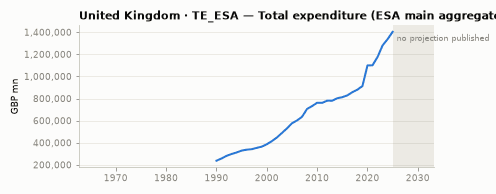

recipe:   1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
both:     NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the same TE envelope constrains the ESA_EXP forecast sum in V15; not
          published as a stitched path


In [11]:
chart("GBR", "TE_ESA")

## 2. France — expenditure by ESA economic type

Nine economic lines and their total. `E03` (cash social benefits) and `E05` (interest) are the two that other publications forecast directly; read `E05` against `GF01_7` in the main book.

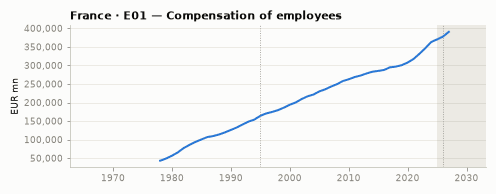

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1978-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [12]:
chart("FRA", "E01")

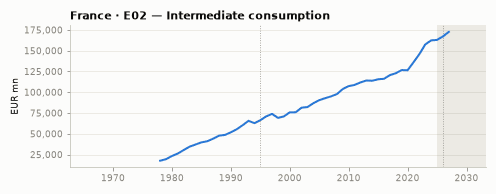

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1978-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [13]:
chart("FRA", "E02")

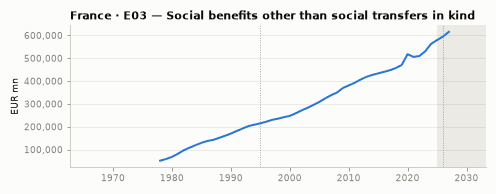

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1978-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [14]:
chart("FRA", "E03")

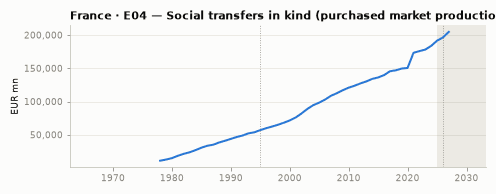

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1978-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [15]:
chart("FRA", "E04")

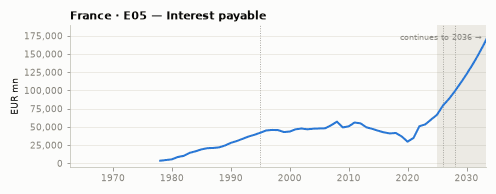

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)  ·
          2028-2036: official forecast (EC_DSM, grade B)
outturn:  1978-2025
both:     projects to 2036 — source horizon: EC_DSM ends 2036 (V10)


In [16]:
chart("FRA", "E05")

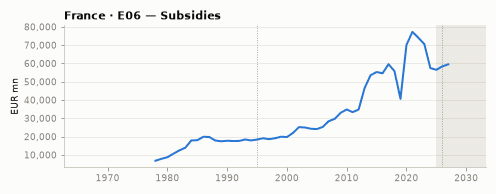

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1978-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [17]:
chart("FRA", "E06")

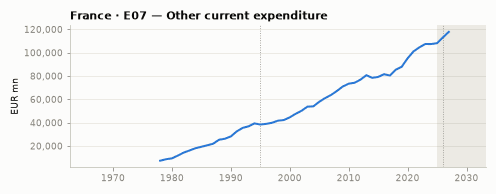

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: derived by identity
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1978-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [18]:
chart("FRA", "E07")

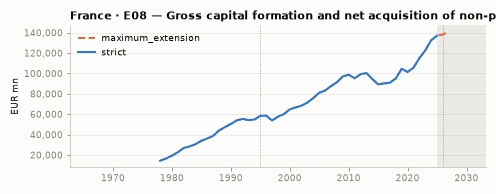

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: derived by identity
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: proxy forecast (EC_AMECO, grade B)
outturn:  1978-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UIGG0
          is gross fixed capital formation (P.51G) only — one component of P.5 + NP; §7.8 single-
          component proxy, applied in maximum_extension to 2027 with the measured share; no official
          forecast of inventories/valuables/non-produced assets exists
maximum:  projects to 2027 — AMECO UIGG0 is gross fixed capital formation (P.51G) only — one component
          of P.5 + NP; §7.8 single-component proxy, applied in maximum_extension to 2027 with the
          measured share; no official forecast of inventories/valuables/non-produced assets exists


In [19]:
chart("FRA", "E08")

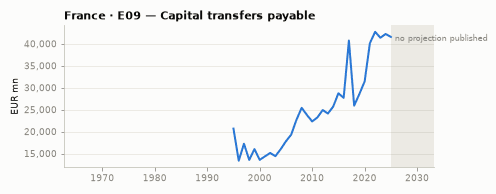

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UKTGT
          (D.9 exactly) stops at the last actual; UKOG (other capital expenditure incl. capital
          transfers) is the forecast candidate — a superset proxy (§7.8), maximum_extension only where
          its measured share is in band


In [20]:
chart("FRA", "E09")

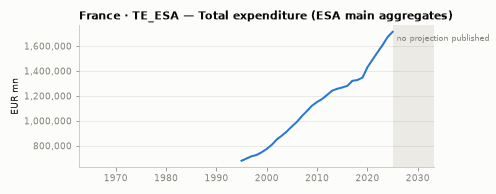

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the same TE envelope constrains the ESA_EXP forecast sum in V15; not
          published as a stitched path


In [21]:
chart("FRA", "TE_ESA")

## 3. Germany — expenditure by ESA economic type

Nine economic lines and their total. `E03` (cash social benefits) and `E05` (interest) are the two that other publications forecast directly; read `E05` against `GF01_7` in the main book.

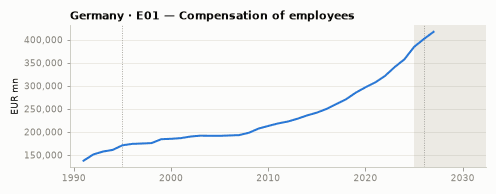

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1991-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [22]:
chart("DEU", "E01")

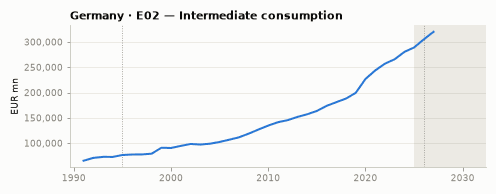

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1991-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [23]:
chart("DEU", "E02")

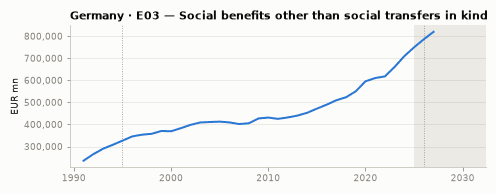

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1991-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [24]:
chart("DEU", "E03")

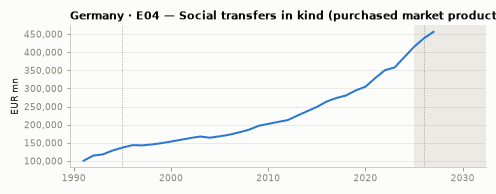

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1991-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [25]:
chart("DEU", "E04")

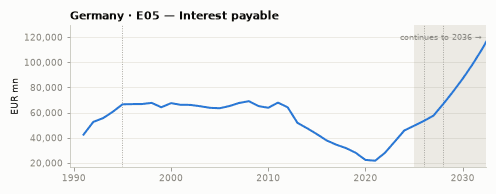

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)  ·
          2028-2036: official forecast (EC_DSM, grade B)
outturn:  1991-2025
both:     projects to 2036 — source horizon: EC_DSM ends 2036 (V10)


In [26]:
chart("DEU", "E05")

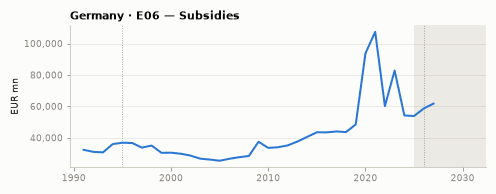

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1991-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [27]:
chart("DEU", "E06")

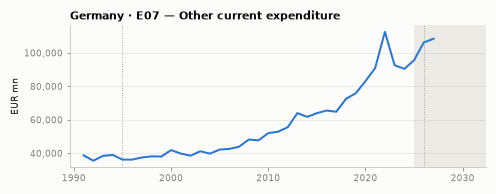

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: derived by identity
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1991-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [28]:
chart("DEU", "E07")

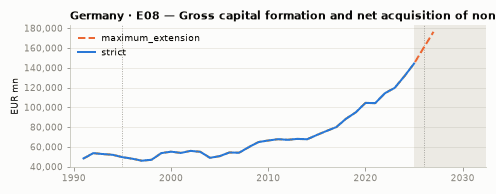

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: derived by identity
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: proxy forecast (EC_AMECO, grade B)
outturn:  1991-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UIGG0
          is gross fixed capital formation (P.51G) only — one component of P.5 + NP; §7.8 single-
          component proxy, applied in maximum_extension to 2027 with the measured share; no official
          forecast of inventories/valuables/non-produced assets exists
maximum:  projects to 2027 — AMECO UIGG0 is gross fixed capital formation (P.51G) only — one component
          of P.5 + NP; §7.8 single-component proxy, applied in maximum_extension to 2027 with the
          measured share; no official forecast of inventories/valuables/non-produced assets exists


In [29]:
chart("DEU", "E08")

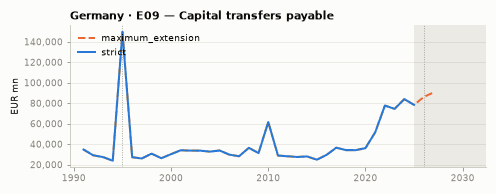

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: proxy forecast (EC_AMECO, grade B)
outturn:  1991-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UKTGT
          (D.9 exactly) stops at the last actual; UKOG (other capital expenditure incl. capital
          transfers) is the forecast candidate — a superset proxy (§7.8), maximum_extension only where
          its measured share is in band
maximum:  projects to 2027 — AMECO UKTGT (D.9 exactly) stops at the last actual; UKOG (other capital
          expenditure incl. capital transfers) is the forecast candidate — a superset proxy (§7.8),
          maximum_extension only where its measured share is in band


In [30]:
chart("DEU", "E09")

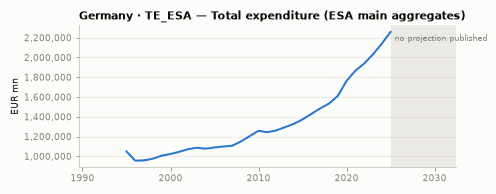

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
both:     NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the same TE envelope constrains the ESA_EXP forecast sum in V15; not
          published as a stitched path


In [31]:
chart("DEU", "TE_ESA")

---

## Seams in the economic tree

The same triage table as the main book's §6, restricted to the `E` lines: every year where the source or method changes, with the year-on-year step across it.

In [32]:
rows = []
for (iso3, line), g in ECONOMIC.query("variant == 'maximum_extension'").groupby(
        ["iso3", "line_code"]):
    for year in _seams(g):
        prev = g.query("year == @year - 1").iloc[0]
        curr = g.query("year == @year").iloc[0]
        rows.append({"iso3": iso3, "line": line, "seam_year": year,
                     "from": f"{prev.observation_type} ({prev.source_id})",
                     "to": f"{curr.observation_type} ({curr.source_id})",
                     "step_pct": round(100 * (curr.value_lcu_mn
                                              / prev.value_lcu_mn - 1), 2)})
seams = pd.DataFrame(rows).sort_values(["iso3", "line", "seam_year"])
print(f"{len(seams)} seams across {seams.groupby(['iso3', 'line']).ngroups} series")
seams.reindex(seams.step_pct.abs().sort_values(ascending=False).index).reset_index(drop=True)

48 seams across 23 series


,iso3,line,seam_year,from,to,step_pct
0,DEU,E09,1995,stitched_actual (EC_AMECO),anchor_actual (EUROSTAT_GOV10A_MAIN),528.66
1,GBR,E09,1990,stitched_actual (EC_AMECO),anchor_actual (ONS_GG_RECEIPTS),191.07
2,GBR,E08,1990,stitched_actual (EC_AMECO),derived_actual (ONS_GG_RECEIPTS),21.99
3,FRA,E05,2026,anchor_actual (EUROSTAT_GOV10A_MAIN),direct_forecast (EC_AMECO),19.04
4,DEU,E05,2028,direct_forecast (EC_AMECO),direct_forecast (EC_DSM),15.99
5,GBR,E04,1990,stitched_actual (EC_AMECO),anchor_actual (ONS_GG_RECEIPTS),13.15
6,FRA,E05,2028,direct_forecast (EC_AMECO),direct_forecast (EC_DSM),11.97
7,DEU,E08,2026,derived_actual (EUROSTAT_GOV10A_MAIN),proxy_forecast (EC_AMECO),11.23
8,DEU,E07,2026,derived_actual (EUROSTAT_GOV10A_MAIN),direct_forecast (EC_AMECO),11.11
9,GBR,E06,1990,stitched_actual (EC_AMECO),anchor_actual (ONS_GG_RECEIPTS),10.77
